In [1]:
import zipfile
import tempfile
import pathlib
import struct

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
from nn import Linear, ReLU, Logistic, Tanh, Softmax, SGD, MSELoss, CrossEntropyLoss, Tensor, Sequential

## Extraction des données

In [4]:
def charger_images_mnist(chemin_fichier):
    """Charge un fichier d'images MNIST (.idx3-ubyte) et le prépare pour l'ACP."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
    return images

def charger_labels_mnist(chemin_fichier):
    """Charge un fichier d'étiquettes MNIST (.idx1-ubyte)."""
    with open(chemin_fichier, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [5]:
chemin_donnees = "../../../../Données/mnist.zip"  # A adapter selon vos besoins
tmp = pathlib.Path(tempfile.gettempdir())
chemin_travail = tmp.joinpath("MNIST")

In [6]:
archive = zipfile.ZipFile(chemin_donnees)
archive.extractall(chemin_travail)

In [7]:
images_train = charger_images_mnist(chemin_travail.joinpath("train-images-idx3-ubyte").joinpath("train-images-idx3-ubyte"))
labels_train = charger_labels_mnist(chemin_travail.joinpath("train-labels-idx1-ubyte").joinpath("train-labels-idx1-ubyte"))
images_train.shape, labels_train.shape

((60000, 784), (60000,))

In [8]:
images_test = charger_images_mnist(chemin_travail.joinpath("t10k-images-idx3-ubyte").joinpath("t10k-images-idx3-ubyte"))
labels_test = charger_labels_mnist(chemin_travail.joinpath("t10k-labels-idx1-ubyte").joinpath("t10k-labels-idx1-ubyte"))
images_test.shape, labels_test.shape

((10000, 784), (10000,))

Normalisation des images:

In [9]:
images_train = images_train / 255.
images_test = images_test / 255.

## Fonctions de visualisation

In [10]:
def visualiser_image(images, labels, index = None, label = None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    plt.imshow(image, cmap="gray", vmin=0., vmax=1.)
    plt.axis("off")
    plt.title(label)

In [11]:
def visualiser_image_classification(images, labels, scores, index=None, label=None):
    if index is None:
        index = np.random.choice(images.shape[0])
    image = images[index]
    p = image.shape[0]
    image = image.reshape(int(np.sqrt(p)), int(np.sqrt(p)))
    if label is None:
        label = f"{labels[index]}"
    else:
        label = f"{label}: {labels[index]}"
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.imshow(image, cmap="gray", vmin=0., vmax=1.)
    ax1.axis("off")
    ax1.set_title(f"Index = {index} / Classe vraie = {label}")
    divider = make_axes_locatable(ax1)
    ax2 = divider.append_axes("right", size="100%", pad=0.5)
    probabs = scores[index]
    classe_predite = np.argmax(probabs)
    barres = ax2.barh(range(10), probabs, color="tab:blue")
    barres[classe_predite].set_color("tab:orange")
    ax2.set_yticks(range(10), range(10))
    ax2.set_xlim(0, 1.)
    ax2.set_title("probabilités")

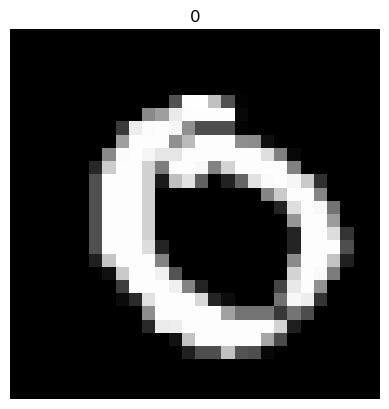

In [12]:
visualiser_image(images_train, labels_train)

## Entraînement d'un modèle de classification

In [13]:
images_train.shape

(60000, 784)

In [14]:
labels_train.shape

(60000,)

In [15]:
binarizer = LabelBinarizer()
binarizer.fit(labels_train)

,"neg_label neg_label: int, default=0Value with which negative labels must be encoded.",0
,"pos_label pos_label: int, default=1Value with which positive labels must be encoded.",1
,"sparse_output sparse_output: bool, default=FalseTrue if the returned array from transform is desired to be in sparseCSR format.",False


In [16]:
X_train = Tensor(images_train)
Y_train = Tensor(binarizer.transform(labels_train))

In [17]:
X_test = Tensor(images_test)
Y_test = Tensor(binarizer.transform(labels_test))

In [65]:
model = Sequential([
    Linear(784, 32),
    ReLU(),
    Linear(32, 10)
])

In [66]:
optim = SGD(model.parameters(), learning_rate=0.01)
loss = CrossEntropyLoss()

In [67]:
clf = Sequential([
    model,
    Softmax()  # on rajoute le softmax pour calculer des probabilités
])

In [81]:
epochs = 1
batch_size = 512
n = X_train.shape[0]
for i in range(epochs):
    j = 0
    while 1:
        # Batch courant
        _X = X_train[j:j+batch_size]
        _Y = Y_train[j:j+batch_size]
        # Passe avant
        Yhat= model(X_train)
        loss(Yhat, Y_train)
        # Rétro-propagation du gradient
        grad = loss.backward()
        model.backward(grad)
        # Optimisation
        optim.step()
        # Batch suivant
        j += batch_size
        print("#", end="")
        if j >= n:
            print("")
            break

######################################################################################################################


In [82]:
Yh = clf(X_test)

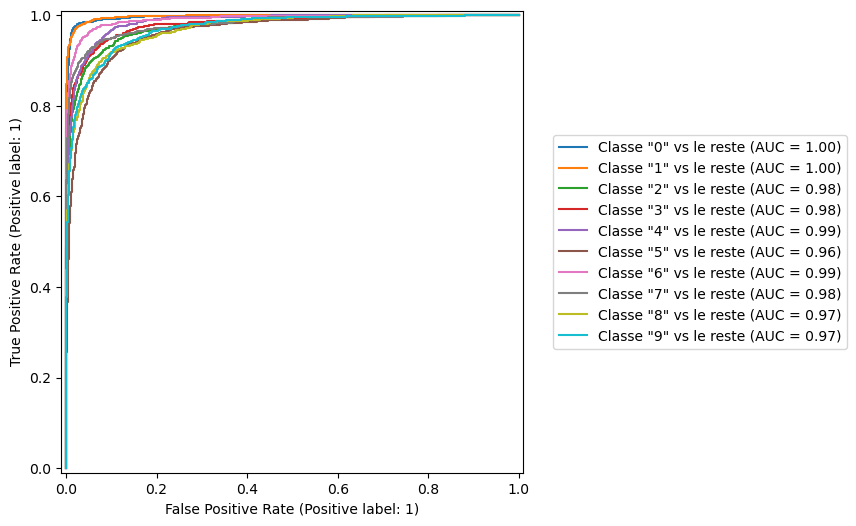

In [83]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(10):
    RocCurveDisplay.from_predictions(y_true=Y_test.data[:,i], y_score=Yh.data[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

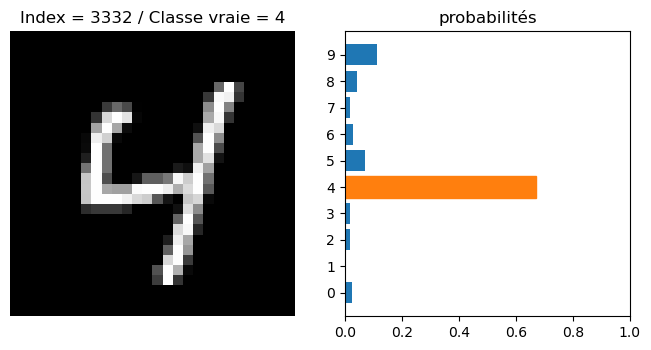

In [85]:
visualiser_image_classification(images_test, labels_test, Yh.data, index=None)

## Un premier auto-encodeur !

In [104]:
encoder = Sequential([
    Linear(784, 32),
    ReLU(),
    Linear(32, 16),
    ReLU(),
    Linear(16, 8)
])

In [105]:
decoder = Sequential([
    Linear(8, 16),
    ReLU(),
    Linear(16, 32),
    ReLU(),
    Linear(32, 784, init="xavier"),
    Logistic()
])

In [106]:
model = Sequential([
    encoder,
    decoder
])

In [107]:
optim = SGD(model.parameters(), learning_rate=0.01)
loss = MSELoss()

In [108]:
epochs = 1
batch_size = 512
n = X_train.shape[0]
for i in range(epochs):
    j = 0
    while 1:
        # Batch courant
        _X = X_train[j:j+batch_size]
        # Passe avant
        Yhat= model(X_train)
        loss(Yhat, X_train)  # non, non, ce n'est pas une erreur ;)
        # Rétro-propagation du gradient
        grad = loss.backward()
        model.backward(grad)
        # Optimisation
        optim.step()
        # Batch suivant
        j += batch_size
        print("#", end="")
        if j >= n:
            print("")
            break

######################################################################################################################


C'est beaucoup trop lent ! On va passer à une librairie industrielle: PyTorch.